In [1]:
import pandas as pd
import numpy as np
from scipy.stats import beta

from plotnine import *


In [1]:
or_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/results/res_202511/gene_expression_outliers.tsv", sep="\t")

NameError: name 'pd' is not defined

In [3]:
or_res["IMPACT_bool"] = or_res["IMPACT"] == "HIGH"


,sampleID,total_outliers,impact_true,prop_impact_true
0,07R9,81,0,0.000000
1,1174YV,7,0,0.000000
2,11AWE1,17,2,0.117647
3,11FX5L,3,0,0.000000
4,11LQ1G,21,0,0.000000


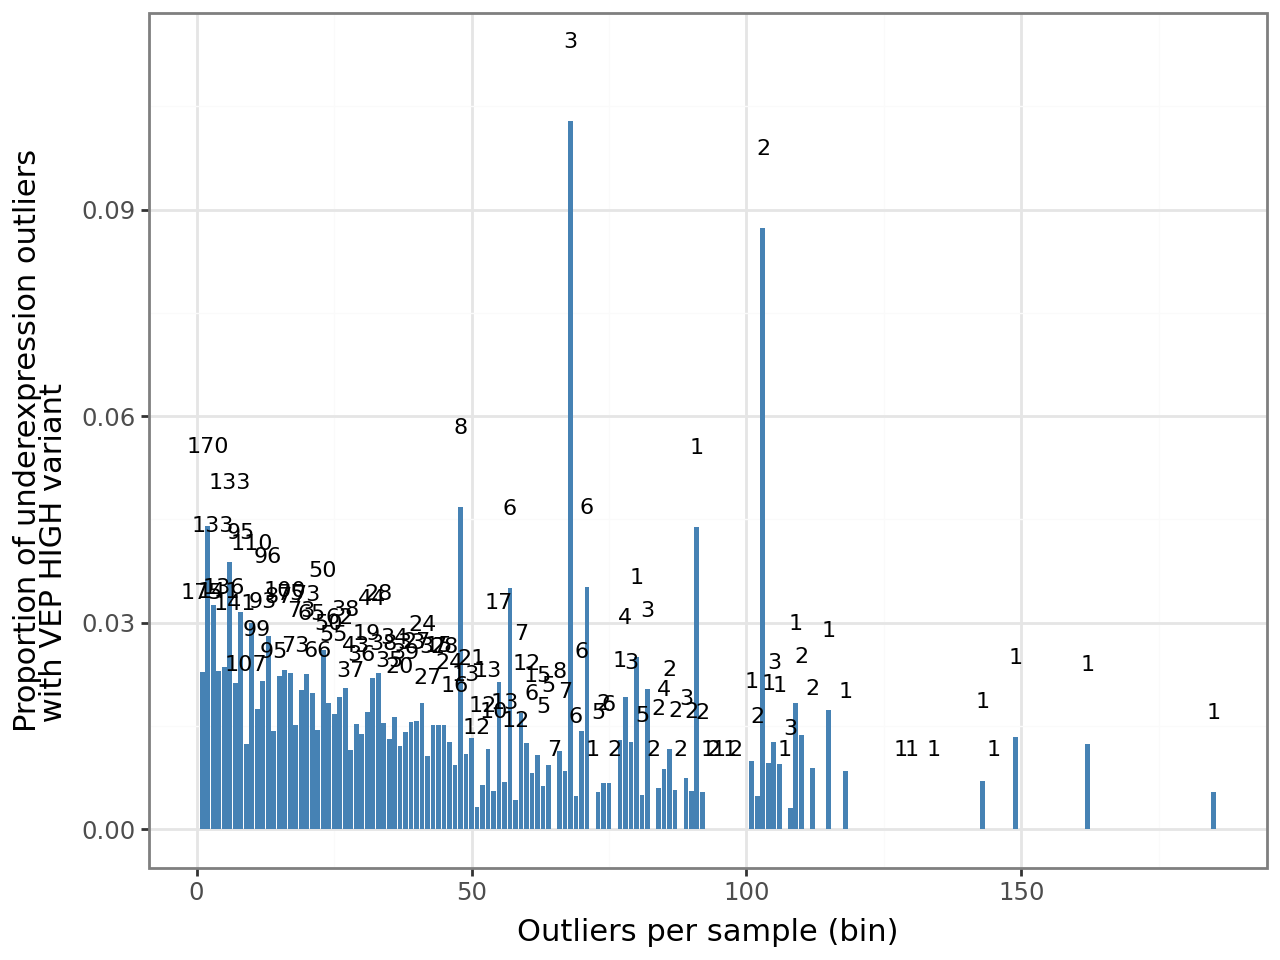

In [15]:
summary = or_res.groupby('sampleID').agg(
    total_outliers=('IMPACT_bool', 'size'),
    impact_true=('IMPACT_bool', 'sum')
).reset_index()

# proportion of outliers with impact = True
summary['prop_impact_true'] = summary['impact_true'] / summary['total_outliers']
summary.head()
group_summary = summary.groupby('total_outliers').agg(
    mean_prop_impact_true=('prop_impact_true', 'mean'),
    n_samples=('sampleID', 'nunique')
).reset_index()
p = (
    ggplot(group_summary, aes('total_outliers', 'mean_prop_impact_true'))
    + geom_bar(stat='identity', fill='steelblue')
    + geom_text(
        aes(label='n_samples'),
        va='bottom',
        size=8,
        nudge_y=0.01
    )
    + labs(
        x='Outliers per sample (bin)',
        y='Proportion of underexpression outliers\n with VEP HIGH variant',
    )
    + theme_bw()
)

p


In [19]:
bins = [0, 1, 3, 5, 10, 20, 50, 100, 150,  float('inf')]
labels = [
    "1",
    "2",
    "3–5",
    "6-10",
    "11–20",
    "21–40",
    "41–60",
    "61-150",
    "151+"
]

summary['outlier_bin'] = pd.cut(
    summary['total_outliers'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

In [20]:
group_summary = (
    summary.groupby('outlier_bin')
           .agg(
               mean_prop_impact_true=('prop_impact_true', 'mean'),
               n_samples=('sampleID', 'nunique')
           )
           .reset_index()
)
group_summary['outlier_bin'] = pd.Categorical(
    group_summary['outlier_bin'],
    categories=labels,
    ordered=True
)

/tmp/ipykernel_2336314/2699809373.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [23]:
summary

,sampleID,total_outliers,impact_true,prop_impact_true,outlier_bin
0,07R9,81,0,0.000000,41–60
1,1174YV,7,0,0.000000,6-10
2,11AWE1,17,2,0.117647,11–20
3,11FX5L,3,0,0.000000,2
4,11LQ1G,21,0,0.000000,21–40
...,...,...,...,...,...
3511,ZZ8LX4,40,0,0.000000,21–40
3512,ZZK84Z,18,0,0.000000,11–20
3513,ZZMJ1D,9,0,0.000000,6-10
3514,ZZU2PY,24,1,0.041667,21–40


In [44]:
from plotnine import (
    ggplot, aes, geom_bar, geom_text, geom_col
    theme_minimal, labs
)

p = (
    ggplot(group_summary, aes('outlier_bin', 'mean_prop_impact_true'))
    + geom_bar(stat='identity', fill='steelblue')
    + geom_text(
        aes(label='n_samples'),
        va='bottom',
        size=8,
        nudge_y=0.01
    )
    + labs(
        x='Sample outlier count group',
        y='Mean proportion of IMPACT_bool == True',
    )
    + theme_bw()
)
p

SyntaxError: invalid syntax (1263096344.py, line 3)

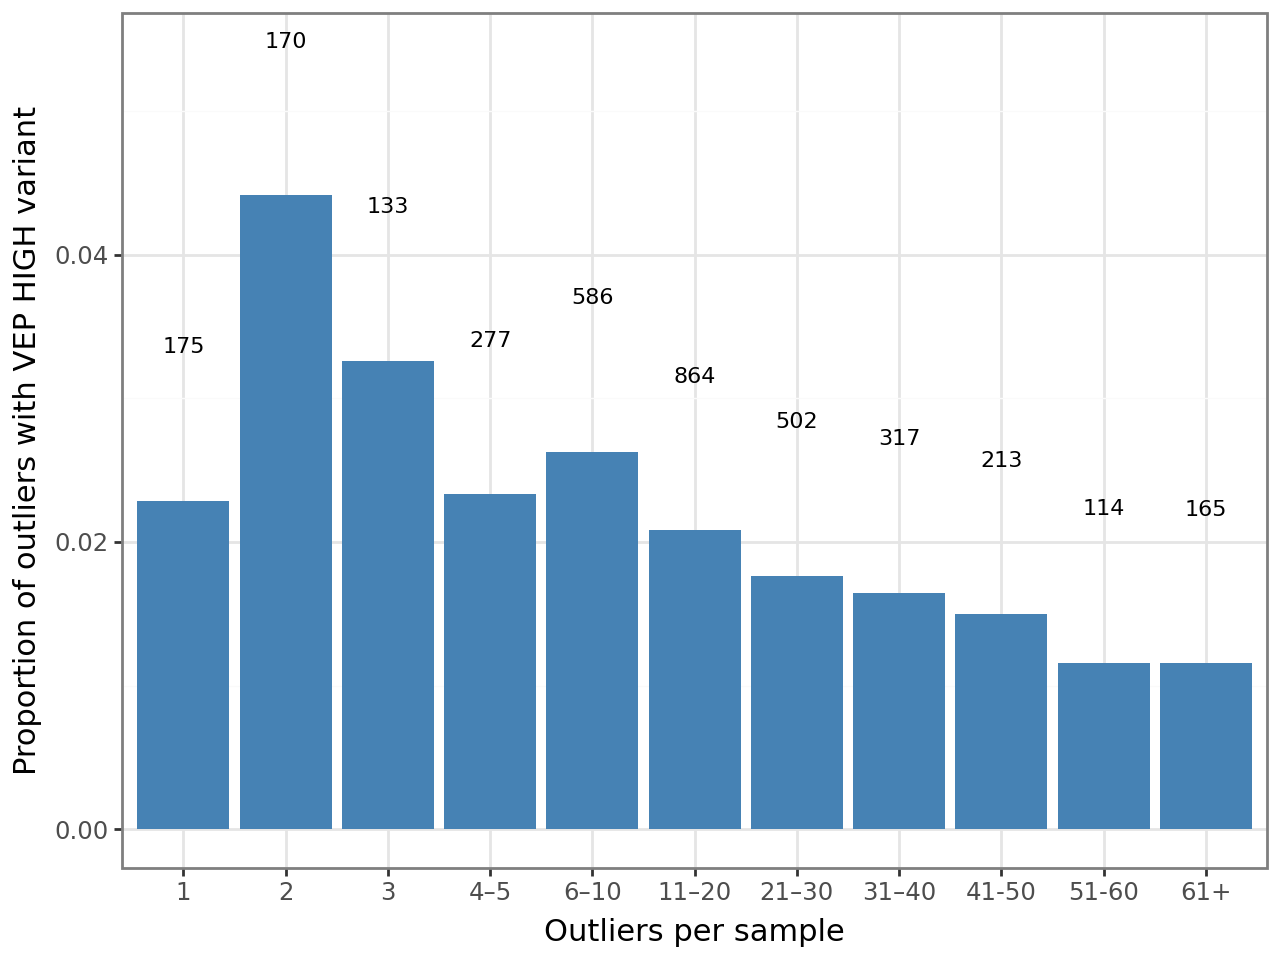

In [56]:
summary = (
    or_res.groupby('sampleID')
      .agg(
          total_outliers=('IMPACT_bool', 'size'),
          impact_true=('IMPACT_bool', 'sum')   # number of TRUEs in that sample
      )
      .reset_index()
)

# --- 2) Define bins and labels (your provided bins) ---
bins = [0, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60, float('inf')]
labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11–20",
    "21–30",
    "31–40",
    "41-50",
    "51-60",
    "61+"
]

summary['outlier_bin'] = pd.cut(
    summary['total_outliers'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# If you prefer to *exclude* samples with total_outliers == 0, uncomment:
# summary = summary[summary['total_outliers'] > 0]

# Ensure category order
summary['outlier_bin'] = pd.Categorical(summary['outlier_bin'], categories=labels, ordered=True)

# --- 3) Aggregate correctly by summing impacted and total outliers per bin ---
group_summary = (
    summary.groupby('outlier_bin', observed=True)
           .agg(
               sum_impact_true=('impact_true', 'sum'),
               sum_total_outliers=('total_outliers', 'sum'),
               n_samples=('sampleID', 'nunique')
           )
           .reset_index()
)

# Compute correct proportion: total impacted / total outliers in bin
# Protect against division by zero (if a bin has sum_total_outliers == 0)
group_summary['prop_impact_true'] = (
    group_summary['sum_impact_true'] / group_summary['sum_total_outliers']
).replace([np.inf, -np.inf], np.nan)

# also add a pretty percent label for annotations
group_summary['prop_pct_label'] = (group_summary['prop_impact_true'] * 100).round(1).astype(str) + '%'

print(summary["total_outliers"].quantile(0.95))

# --- 4) Bar plot with plotnine ---
p = (
    ggplot(group_summary, aes('outlier_bin', 'prop_impact_true'))
    + geom_bar(stat='identity', fill='steelblue')
    + geom_text(
        aes(label='n_samples'),
        va='bottom',
        size=8,
        nudge_y=0.01
    )
    + labs(
        x='Outliers per sample',
        y='Proportion of outliers with VEP HIGH variant',
    )
    + theme_bw()
)
p


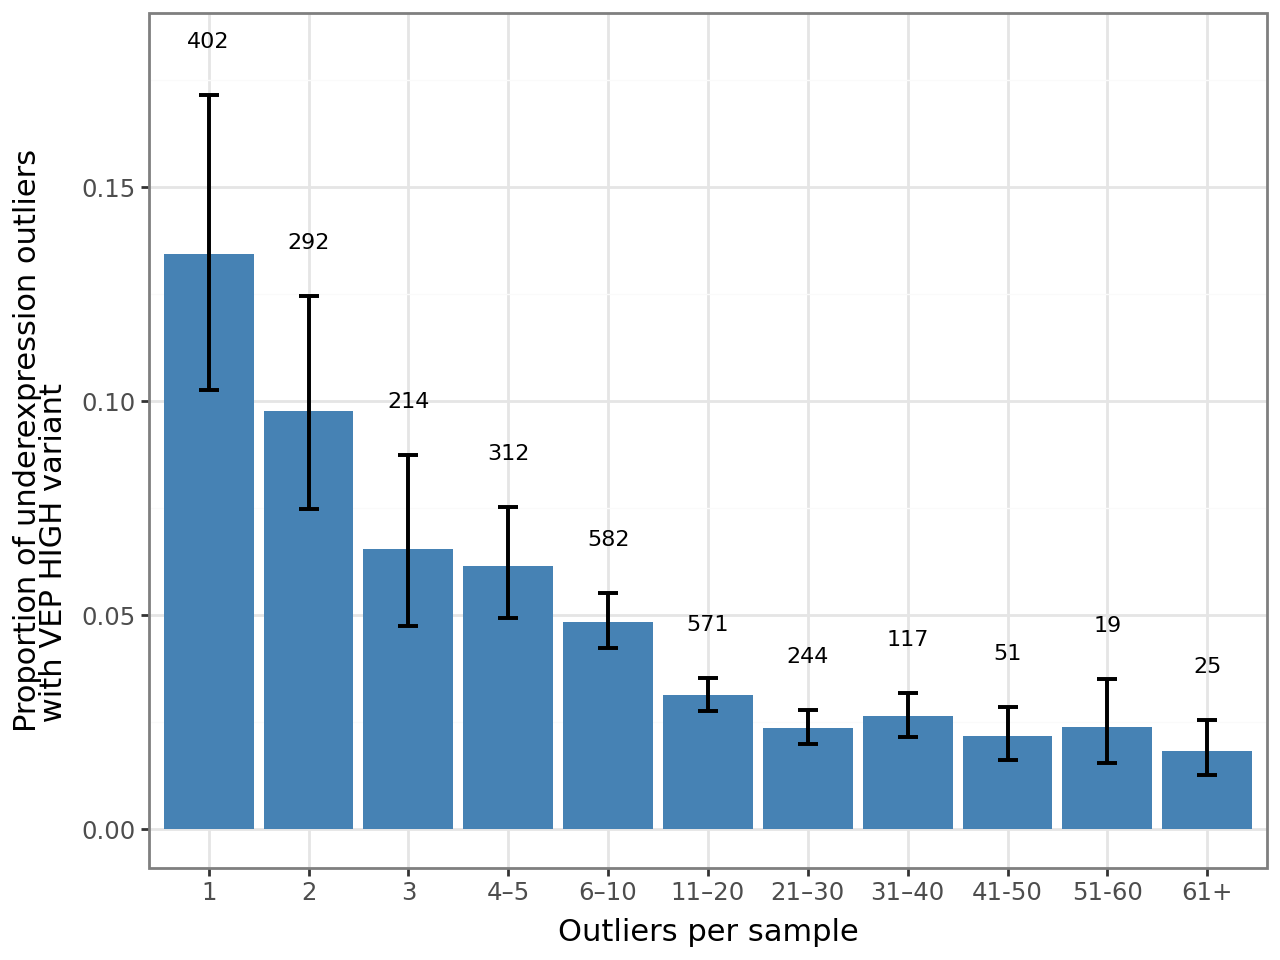

In [71]:
summary = (
    or_res[or_res["zScore"] <= 0].groupby('sampleID')
      .agg(
          total_outliers=('IMPACT_bool', 'size'),
          impact_true=('IMPACT_bool', 'sum')   # number of TRUEs in that sample
      )
      .reset_index()
)

# --- 2) Define bins and labels (your provided bins) ---
bins = [0, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60, float('inf')]
labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11–20",
    "21–30",
    "31–40",
    "41-50",
    "51-60",
    "61+"
]

summary['outlier_bin'] = pd.cut(
    summary['total_outliers'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# If you prefer to *exclude* samples with total_outliers == 0, uncomment:
# summary = summary[summary['total_outliers'] > 0]

# Ensure category order
summary['outlier_bin'] = pd.Categorical(summary['outlier_bin'], categories=labels, ordered=True)

# --- 3) Aggregate correctly by summing impacted and total outliers per bin ---
group_summary = (
    summary.groupby('outlier_bin', observed=True)
           .agg(
               sum_impact_true=('impact_true', 'sum'),
               sum_total_outliers=('total_outliers', 'sum'),
               n_samples=('sampleID', 'nunique')
           )
           .reset_index()
)

# Compute correct proportion: total impacted / total outliers in bin
# Protect against division by zero (if a bin has sum_total_outliers == 0)
group_summary['prop_impact_true'] = (
    group_summary['sum_impact_true'] / group_summary['sum_total_outliers']
).replace([np.inf, -np.inf], np.nan)

# also add a pretty percent label for annotations
group_summary['prop_pct_label'] = (group_summary['prop_impact_true'] * 100).round(1).astype(str) + '%'

x = group_summary.sum_impact_true
under_rank = group_summary.sum_total_outliers

# Vectorized Clopper–Pearson
alpha = 0.05
group_summary['ci_min'] = beta.ppf(alpha/2, x, under_rank - x + 1)
group_summary['ci_max'] = beta.ppf(1 - alpha/2, x + 1, under_rank - x)

# --- 4) Bar plot with plotnine ---
p = (
    ggplot(group_summary, aes('outlier_bin', 'prop_impact_true'))
    + geom_bar(stat='identity', fill='steelblue')
    + geom_text(
        aes(label='n_samples', y="ci_max"),
        va='bottom',
        size=8,
        nudge_y=0.01
    ) + geom_errorbar(
        aes(ymin='ci_min', ymax='ci_max'),
        width=0.2,
        size=0.8
    )
    + labs(
        x='Outliers per sample',
        y='Proportion of underexpression outliers\n with VEP HIGH variant',
    )
    + theme_bw()
)
p
